# A reconstruction nosie dependence on CMB white noise level
This code compute normalization and power spectrum of quadratic estiamtors with varying CMB noise level

In [1]:
# external
import numpy as np
from matplotlib.pyplot import *
# from cmblensplus
from cmblensplus import curvedsky as cs
from cmblensplus.utils import plottools as pl, cmb

Importing /global/u1/t/toshiyan/.conda/envs/py_v3_13/lib/python3.13/site-packages/cmblensplus/utils/__init__.py


First define parameters

In [2]:
Tcmb  = 2.726e6    # CMB temperature
Lmin, Lmax  = 2, 2048       # maximum multipole of output normalization
rlmin, rlmax = 100, 4096  # CMB multipole range for reconstruction
L = np.linspace(0,Lmax,Lmax+1)
Lfac = (L*(L+1.))**2/(2*np.pi)
ac2rad = np.pi/10800.
lTmax = 3000
quad = ['TT','TE','EE','TB','EB','MV']
QDO = [True,True,True,True,True,False] # this means that TT, TE, EE, TB and EB are used for MV estimator

Load arrays of CMB unlensed and lensed Cls. Unlensed Cls are not used for now. The Cls should not be multiplied by any factors and should not have units.  

In [3]:
# ucl is an array of shape [0:5,0:rlmax+1] and ucl[0,:] = TT, ucl[1,:] = EE, ucl[2,:] = TE, lcl[3,:] = phiphi, lcl[4,:] = Tphi
ucl = cmb.read_camb_cls('../data/unlensedcls.dat',ftype='scal',output='array')[:,:rlmax+1] # TT, EE, TE, pp, Tp
# lcl is an array of shape [0:4,0:rlmax+1] and lcl[0,:] = TT, lcl[1,:] = EE, lcl[2,:] = BB, and lcl[3,:] = TE
lcl = cmb.read_camb_cls('../data/lensedcls.dat',ftype='lens',output='array')[:,:rlmax+1] # TT, EE, BB, TE

Loop over SNR calculation

In [4]:
sigs = [3,4,5,8,10,20,30,50]
snr = np.zeros((6,len(sigs)))
for i, sig in enumerate(sigs):
    nl  = np.zeros((4,rlmax+1))
    nl[0,:] = (sig*ac2rad/Tcmb)**2
    nl[1,:] = 2*nl[0,:]
    nl[2,:] = 2*nl[0,:]
    nl[0,lTmax+1:] = 1e30
    ocl = lcl + nl
    Ag, Ac, Wg, Wc = cs.norm_quad.qall('lens',QDO,Lmax,rlmin,rlmax,lcl,ocl)
    for qi in range(6):
        var_lm = ( ucl[3,Lmin:Lmax+1] + Ag[qi,Lmin:Lmax+1] ) 
        snr[qi,i] = np.sqrt( np.sum( (L[Lmin:Lmax+1]+.5) * ucl[3,Lmin:Lmax+1]**2/var_lm**2 ) )
    print(snr[:,i])

 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
[188.11301556  92.73707683 145.52080718  62.63916733 278.80135588
 371.98896267]
 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
[186.47065252  88.04186664 122.45600158  45.2655532  221.72408412
 323.4011906 ]
 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
[184.43120597  83.90243698 107.31348417  33.74141693 179.6826777
 290.38384348]
 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
[176.41149091  73.7098893   81.05161897  16.27806358 102.74542861
 234.6955347 ]


IOStream.flush timed out


 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
[169.97950603  68.13666721  70.15743202  11.04333561  73.88542295
 213.49828695]
 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
[135.70441677  47.81925871  38.25983085   2.98949627  19.74827243
 155.02881076]
 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
[108.06778946  34.60657098  21.58094129   1.33756319   7.44163655
 121.17220432]
 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
[73.59779285 19.28985598  7.32138339  0.47382799  1.77172748 81.54604472]


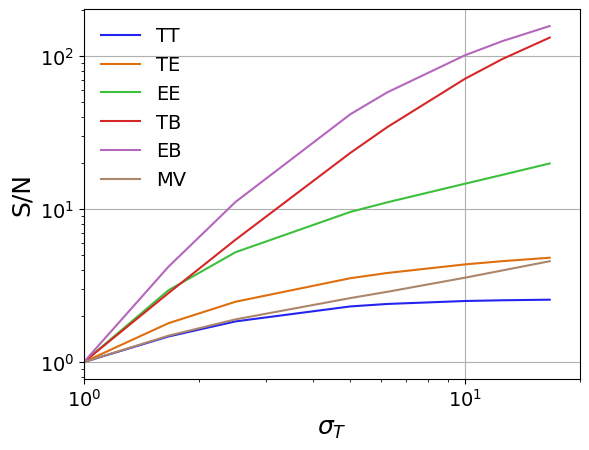

In [5]:
pl.plot_1dstyle(xmin=1,xmax=20,xlab=r'$\sigma_T$',ylab='S/N',xlog=True,ylog=True,grid=True)
x = 50./np.array(sigs)
for qi, q in enumerate(quad):
    plot(x,snr[qi,:]/snr[qi,-1],label=q)
legend()